# Sudoku Solver using Simulated Annealing

## Introduction
This notebook demonstrates how to solve Sudoku puzzles using **Simulated Annealing (SA)**, a probabilistic technique for approximating the global optimum of a given function. 

Unlike backtracking algorithms that guarantee a solution but can be slow, SA is a **metaheuristic** that mimics the physical process of heating a material and then slowly lowering the temperature to decrease defects (minimize system energy).

## The Approach
1.  **Representation**: The Sudoku grid is initialized such that every **3x3 subgrid** contains the numbers 1-9 exactly once. This satisfies one of the three Sudoku constraints immediately.
2.  **Neighbor Operator**: We generate new states by randomly **swapping two numbers** within a 3x3 block. This preserves the subgrid constraint.
3.  **Cost Function (Energy)**: The "energy" of the system is the number of conflicts in the **Rows** and **Columns**. A solved Sudoku has a cost of 0.
4.  **Cooling Schedule**: The rate at which the "temperature" drops determines how likely the algorithm is to accept worse solutions (to escape local minima). We will explore:
    *   **Linear Cooling**
    *   **Exponential Cooling**
    *   **Adaptive Cooling**

In [1]:
!pip install numpy

In [2]:
import random
import numpy as np
import math
from random import choice
import statistics

In [3]:
startingSudoku = """
                    094006032
                    570020000
                    200005080
                    907800605
                    006090300
                    830007010
                    005000001
                    020150467
                    700600203
                """

sudoku = np.array([[int(i) for i in line] for line in startingSudoku.split()])

In [4]:
def PrintSudoku(sudoku):
    print("\n")
    for i in range(len(sudoku)):
        line = ""
        if i == 3 or i == 6:
            print("---------------------")
        for j in range(len(sudoku[i])):
            if j == 3 or j == 6:
                line += "| "
            line += str(sudoku[i,j])+" "
        print(line)

In [5]:
PrintSudoku(sudoku)



0 9 4 | 0 0 6 | 0 3 2 
5 7 0 | 0 2 0 | 0 0 0 
2 0 0 | 0 0 5 | 0 8 0 
---------------------
9 0 7 | 8 0 0 | 6 0 5 
0 0 6 | 0 9 0 | 3 0 0 
8 3 0 | 0 0 7 | 0 1 0 
---------------------
0 0 5 | 0 0 0 | 0 0 1 
0 2 0 | 1 5 0 | 4 6 7 
7 0 0 | 6 0 0 | 2 0 3 


In [6]:
def FixSudokuValues(fixed_sudoku):
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                fixed_sudoku[i,j] = 1

    return(fixed_sudoku)

In [7]:
#FixSudokuValues(fixed_sudoku=sudoku)

In [8]:
sudoku

array([[0, 9, 4, 0, 0, 6, 0, 3, 2],
       [5, 7, 0, 0, 2, 0, 0, 0, 0],
       [2, 0, 0, 0, 0, 5, 0, 8, 0],
       [9, 0, 7, 8, 0, 0, 6, 0, 5],
       [0, 0, 6, 0, 9, 0, 3, 0, 0],
       [8, 3, 0, 0, 0, 7, 0, 1, 0],
       [0, 0, 5, 0, 0, 0, 0, 0, 1],
       [0, 2, 0, 1, 5, 0, 4, 6, 7],
       [7, 0, 0, 6, 0, 0, 2, 0, 3]])

In [9]:
sudoku[:,1] # column

array([9, 7, 0, 0, 0, 3, 0, 2, 0])

In [10]:
sudoku[1,:]

array([5, 7, 0, 0, 2, 0, 0, 0, 0])

## Cost Function (Energy)
Since our representation guarantees that all 3x3 subgrids are valid, we only need to count duplicate numbers in the **Rows** and **Columns**.

The cost function calculates:
$$ Cost = \sum_{rows} (9 - \text{unique\_nums}) + \sum_{cols} (9 - \text{unique\_nums}) $$

A cost of 0 means all rows and columns have 9 unique numbers, implying a valid solution.

In [11]:
def CalculateNumberOfErrorsRowColumn(row, column, sudoku):
    numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))
    return(numberOfErrors)

In [12]:
#numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))

In [13]:
for i in range(0,9):
      numberOfErrors = (9 - len(np.unique(sudoku[:,i]))) + (9 - len(np.unique(sudoku[i,:])))
      print('numberOfErrors',numberOfErrors)

numberOfErrors 6
numberOfErrors 9
numberOfErrors 9
numberOfErrors 8
numberOfErrors 10
numberOfErrors 9
numberOfErrors 10
numberOfErrors 6
numberOfErrors 7


In [14]:
def CalculateNumberOfErrors(sudoku):
    numberOfErrors = 0
    for i in range (0,9):
        numberOfErrors += CalculateNumberOfErrorsRowColumn(i ,i ,sudoku)
    return(numberOfErrors)

In [15]:
CalculateNumberOfErrors(sudoku)

74

## Grid Representation & Neighbor Generation
To reduce the search space, we treat the grid as a collection of nine 3x3 blocks. 
*   **Initialization**: We randomly fill each block with numbers 1-9 (respecting fixed digits).
*   **Swapping**: When generating a neighbor state, we swap two non-fixed numbers *within the same block*. This ensures the block remains valid.

In [16]:
def CreateList3x3Blocks ():
    finalListOfBlocks = []
    for r in range (0,9):
        tmpList = []
        block1 = [i + 3*((r)%3) for i in range(0,3)]
        block2 = [i + 3*math.trunc((r)/3) for i in range(0,3)]
        for x in block1:
            for y in block2:
                tmpList.append([x,y])
            #print(block1)
            #print('b2',block2)
        finalListOfBlocks.append(tmpList)
    return(finalListOfBlocks)

In [17]:
CreateList3x3Blocks ()

[[[0, 0], [0, 1], [0, 2], [1, 0], [1, 1], [1, 2], [2, 0], [2, 1], [2, 2]],
 [[3, 0], [3, 1], [3, 2], [4, 0], [4, 1], [4, 2], [5, 0], [5, 1], [5, 2]],
 [[6, 0], [6, 1], [6, 2], [7, 0], [7, 1], [7, 2], [8, 0], [8, 1], [8, 2]],
 [[0, 3], [0, 4], [0, 5], [1, 3], [1, 4], [1, 5], [2, 3], [2, 4], [2, 5]],
 [[3, 3], [3, 4], [3, 5], [4, 3], [4, 4], [4, 5], [5, 3], [5, 4], [5, 5]],
 [[6, 3], [6, 4], [6, 5], [7, 3], [7, 4], [7, 5], [8, 3], [8, 4], [8, 5]],
 [[0, 6], [0, 7], [0, 8], [1, 6], [1, 7], [1, 8], [2, 6], [2, 7], [2, 8]],
 [[3, 6], [3, 7], [3, 8], [4, 6], [4, 7], [4, 8], [5, 6], [5, 7], [5, 8]],
 [[6, 6], [6, 7], [6, 8], [7, 6], [7, 7], [7, 8], [8, 6], [8, 7], [8, 8]]]

In [18]:
def RandomlyFill3x3Blocks(sudoku, listOfBlocks):
    for block in listOfBlocks:
        for box in block:
            if sudoku[box[0],box[1]] == 0:
                currentBlock = sudoku[block[0][0]:(block[-1][0]+1),block[0][1]:(block[-1][1]+1)]
                sudoku[box[0],box[1]] = choice([i for i in range(1,10) if i not in currentBlock])
                #print('current block',currentBlock)
    return sudoku

In [19]:
def SumOfOneBlock (sudoku, oneBlock):
    finalSum = 0
    for box in oneBlock:
        finalSum += sudoku[box[0], box[1]]
    return(finalSum)

In [20]:
def TwoRandomBoxesWithinBlock(fixedSudoku, block):
    while (1):
        firstBox = random.choice(block)
        secondBox = choice([box for box in block if box is not firstBox ])

        if fixedSudoku[firstBox[0], firstBox[1]] != 1 and fixedSudoku[secondBox[0], secondBox[1]] != 1:
            return([firstBox, secondBox])


In [21]:
def FlipBoxes(sudoku, boxesToFlip):
    proposedSudoku = np.copy(sudoku)
    placeHolder = proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]]
    proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]] = proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]]
    proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]] = placeHolder
    return (proposedSudoku)

In [22]:
def ProposedState (sudoku, fixedSudoku, listOfBlocks):
    randomBlock = random.choice(listOfBlocks)

    if SumOfOneBlock(fixedSudoku, randomBlock) > 6:
        return(sudoku, 1, 1)
    boxesToFlip = TwoRandomBoxesWithinBlock(fixedSudoku, randomBlock)
    proposedSudoku = FlipBoxes(sudoku,  boxesToFlip)
    return([proposedSudoku, boxesToFlip])

In [23]:
def ChooseNewState (currentSudoku, fixedSudoku, listOfBlocks, sigma):
    proposal = ProposedState(currentSudoku, fixedSudoku, listOfBlocks)
    newSudoku = proposal[0]
    boxesToCheck = proposal[1]
    currentCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], currentSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], currentSudoku)
    newCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], newSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], newSudoku)
    # currentCost = CalculateNumberOfErrors(currentSudoku)
    # newCost = CalculateNumberOfErrors(newSudoku)
    costDifference = newCost - currentCost
    #print('cost_ sigma= \n',costDifference,sigma)
    rho = math.exp(-costDifference/sigma)
    if(np.random.uniform(1,0,1) < rho):
        return([newSudoku, costDifference])

    return([currentSudoku, 0])

In [24]:
def ChooseNumberOfItterations(fixed_sudoku):
    numberOfItterations = 0
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                numberOfItterations += 1
    print('Total number Of Itterations',numberOfItterations)
    return numberOfItterations

In [25]:
def CalculateInitialSigma (sudoku, fixedSudoku, listOfBlocks):
  listOfDifferences = []
  tmpSudoku = sudoku
  for i in range(1,10):
    tmpSudoku = ProposedState(tmpSudoku, fixedSudoku, listOfBlocks)[0]
    listOfDifferences.append(CalculateNumberOfErrors(tmpSudoku))
  return (statistics.pstdev(listOfDifferences))

## The Simulated Annealing Algorithm
The `solveSudoku` function implements the core Metropolis Loop:
1.  Generate a candidate state $S'$.
2.  Calculate $\Delta E = E(S') - E(S)$.
3.  If $\Delta E < 0$ (improvement), accept $S'$.
4.  If $\Delta E > 0$, accept with probability $P = \exp(-\Delta E / T)$.

In [26]:
def solveSudoku (sudoku):
    #f = open("demofile2.txt", "a")
    solutionFound = 0
    while (solutionFound == 0):
        decreaseFactor = 0.99 # coolling factor
        stuckCount = 0
        fixedSudoku = np.copy(sudoku)
        PrintSudoku(sudoku)
        FixSudokuValues(fixedSudoku)
        listOfBlocks = CreateList3x3Blocks()
        tmpSudoku = RandomlyFill3x3Blocks(sudoku, listOfBlocks)
        sigma = CalculateInitialSigma(sudoku, fixedSudoku, listOfBlocks)   # calulating intial tempr
        print(f"Initial Temperatute (sigma)= {sigma}")        
        score = CalculateNumberOfErrors(tmpSudoku)
        print(f"Initial cost function value(score)= {score}")
        itterations = ChooseNumberOfItterations(fixedSudoku)
        #print('fixed itteration', fixedSudoku)#listOfDifference
        if score <= 0:
            solutionFound = 1

        while solutionFound == 0:
            previousScore = score
            for i in range (0, itterations):
                newState = ChooseNewState(tmpSudoku, fixedSudoku, listOfBlocks, sigma)
                tmpSudoku = newState[0]
                scoreDiff = newState[1]
                score += scoreDiff
                print(f"The cost function value (score)={score}")
                #f.write(str(score) + '\n')
                if score <= 0:
                    solutionFound = 1
                    break

            sigma *= decreaseFactor    # temperature shedul
            print(f"Gradually Temperatute is decreasing (sigma)= {sigma}")
            if score <= 0:
                solutionFound = 1
                break
            if score >= previousScore:
                stuckCount += 1
            else:
                stuckCount = 0
            if (stuckCount > 80):
                sigma += 2
            if(CalculateNumberOfErrors(tmpSudoku)==0):
                PrintSudoku(tmpSudoku)
                break
    #f.close()
    return(tmpSudoku)

In [27]:
solution = solveSudoku(sudoku)
print(CalculateNumberOfErrors(solution))
PrintSudoku(solution)



0 9 4 | 0 0 6 | 0 3 2 
5 7 0 | 0 2 0 | 0 0 0 
2 0 0 | 0 0 5 | 0 8 0 
---------------------
9 0 7 | 8 0 0 | 6 0 5 
0 0 6 | 0 9 0 | 3 0 0 
8 3 0 | 0 0 7 | 0 1 0 
---------------------
0 0 5 | 0 0 0 | 0 0 1 
0 2 0 | 1 5 0 | 4 6 7 
7 0 0 | 6 0 0 | 2 0 3 
Initial Temperatute (sigma)= 1.4487116456005886
Initial cost function value(score)= 34
Total number Of Itterations 35
The cost function value (score)=32
The cost function value (score)=34
The cost function value (score)=34
The cost function value (score)=34
The cost function value (score)=35
The cost function value (score)=35
The cost function value (score)=34
The cost function value (score)=34
The cost function value (score)=33
The cost function value (score)=33
The cost function value (score)=33
The cost function value (score)=34
The cost function value (score)=33
The cost function value (score)=33
The cost function value (score)=33
The cost function value (score)=32
The cost function value (score)=32
The cost function value (score)=32

# PLot

## Grid Representation & Neighbor Generation
To reduce the search space, we treat the grid as a collection of nine 3x3 blocks. 
*   **Initialization**: We randomly fill each block with numbers 1-9 (respecting fixed digits).
*   **Swapping**: When generating a neighbor state, we swap two non-fixed numbers *within the same block*. This ensures the block remains valid.



0 2 4 | 0 0 7 | 0 0 0 
6 0 0 | 0 0 0 | 0 0 0 
0 0 3 | 6 8 0 | 4 1 5 
---------------------
4 3 1 | 0 0 5 | 0 0 0 
5 0 0 | 0 0 0 | 0 3 2 
7 9 0 | 0 0 0 | 0 6 0 
---------------------
2 0 9 | 7 1 0 | 8 0 0 
0 4 0 | 0 9 3 | 0 0 0 
3 1 0 | 0 0 4 | 7 5 0 
Initial Temperatute (sigma)= 2.160246899469287
The cost function value (score)=28
The cost function value (score)=28
The cost function value (score)=28
The cost function value (score)=27
The cost function value (score)=27
The cost function value (score)=27
The cost function value (score)=27
The cost function value (score)=27
The cost function value (score)=28
The cost function value (score)=28
The cost function value (score)=28
The cost function value (score)=28
The cost function value (score)=28
The cost function value (score)=28
The cost function value (score)=28
The cost function value (score)=30
The cost function value (score)=30
The cost function value (score)=30
The cost function value (score)=32
The cost function value (score)=34


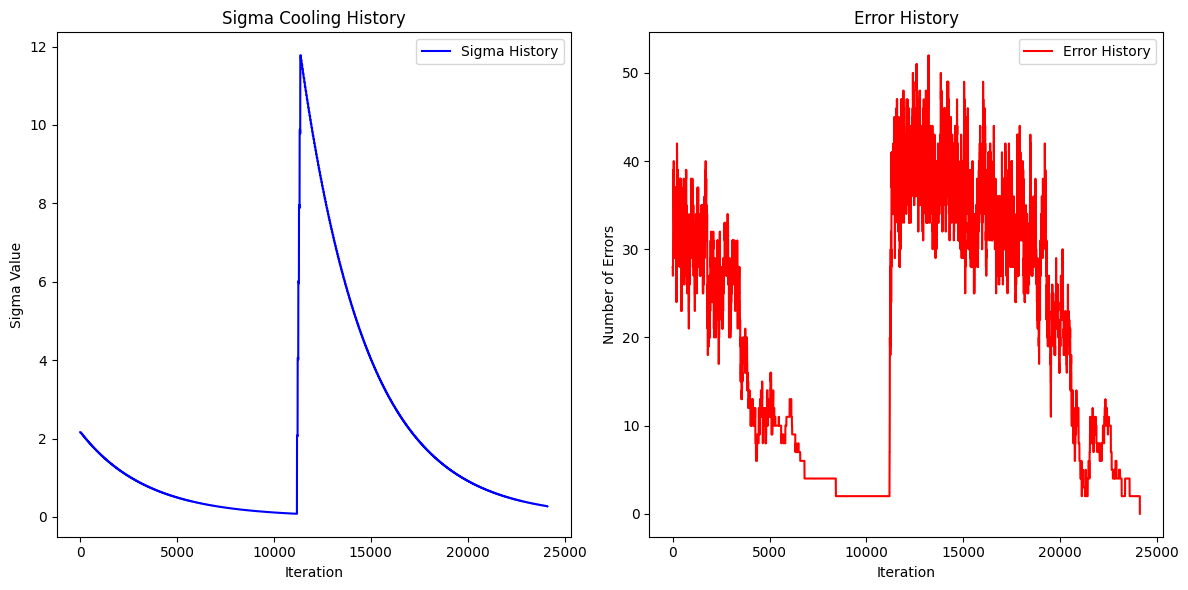

0


1 2 4 | 9 5 7 | 3 8 6 
6 8 5 | 3 4 1 | 2 9 7 
9 7 3 | 6 8 2 | 4 1 5 
---------------------
4 3 1 | 2 6 5 | 9 7 8 
5 6 8 | 4 7 9 | 1 3 2 
7 9 2 | 1 3 8 | 5 6 4 
---------------------
2 5 9 | 7 1 6 | 8 4 3 
8 4 7 | 5 9 3 | 6 2 1 
3 1 6 | 8 2 4 | 7 5 9 


In [28]:
import random
import numpy as np
import math
from random import choice
import statistics
import matplotlib.pyplot as plt

startingSudoku = """
                    024007000
                    600000000
                    003680415
                    431005000
                    500000032
                    790000060
                    209710800
                    040093000
                    310004750
                """

sudoku = np.array([[int(i) for i in line] for line in startingSudoku.split()])

def PrintSudoku(sudoku):
    print("\n")
    for i in range(len(sudoku)):
        line = ""
        if i == 3 or i == 6:
            print("---------------------")
        for j in range(len(sudoku[i])):
            if j == 3 or j == 6:
                line += "| "
            line += str(sudoku[i,j])+" "
        print(line)

def FixSudokuValues(fixed_sudoku):
    for i in range(0, 9):
        for j in range(0, 9):
            if fixed_sudoku[i,j] != 0:
                fixed_sudoku[i,j] = 1
    
    return(fixed_sudoku)

# Cost Function    
def CalculateNumberOfErrors(sudoku):
    numberOfErrors = 0 
    for i in range(0, 9):
        numberOfErrors += CalculateNumberOfErrorsRowColumn(i, i, sudoku)
    return numberOfErrors

def CalculateNumberOfErrorsRowColumn(row, column, sudoku):
    numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))
    return numberOfErrors


def CreateList3x3Blocks():
    finalListOfBlocks = []
    for r in range(0, 9):
        tmpList = []
        block1 = [i + 3*((r) % 3) for i in range(0, 3)]
        block2 = [i + 3 * math.trunc((r) / 3) for i in range(0, 3)]
        for x in block1:
            for y in block2:
                tmpList.append([x, y])
        finalListOfBlocks.append(tmpList)
    return finalListOfBlocks

def RandomlyFill3x3Blocks(sudoku, listOfBlocks):
    for block in listOfBlocks:
        for box in block:
            if sudoku[box[0], box[1]] == 0:
                currentBlock = sudoku[block[0][0]: (block[-1][0] + 1), block[0][1]: (block[-1][1] + 1)]
                sudoku[box[0], box[1]] = choice([i for i in range(1, 10) if i not in currentBlock])
    return sudoku

def SumOfOneBlock(sudoku, oneBlock):
    finalSum = 0
    for box in oneBlock:
        finalSum += sudoku[box[0], box[1]]
    return(finalSum)

def TwoRandomBoxesWithinBlock(fixedSudoku, block):
    while (1):
        firstBox = random.choice(block)
        secondBox = choice([box for box in block if box is not firstBox])

        if fixedSudoku[firstBox[0], firstBox[1]] != 1 and fixedSudoku[secondBox[0], secondBox[1]] != 1:
            return([firstBox, secondBox])

def FlipBoxes(sudoku, boxesToFlip):
    proposedSudoku = np.copy(sudoku)
    placeHolder = proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]]
    proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]] = proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]]
    proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]] = placeHolder
    return (proposedSudoku)

def ProposedState(sudoku, fixedSudoku, listOfBlocks):
    randomBlock = random.choice(listOfBlocks)

    if SumOfOneBlock(fixedSudoku, randomBlock) > 6:  
        return(sudoku, 1, 1)
    boxesToFlip = TwoRandomBoxesWithinBlock(fixedSudoku, randomBlock)
    proposedSudoku = FlipBoxes(sudoku, boxesToFlip)
    return([proposedSudoku, boxesToFlip])

def ChooseNewState(currentSudoku, fixedSudoku, listOfBlocks, sigma):
    proposal = ProposedState(currentSudoku, fixedSudoku, listOfBlocks)
    newSudoku = proposal[0]
    boxesToCheck = proposal[1]
    currentCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], currentSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], currentSudoku)
    newCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], newSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], newSudoku)
    costDifference = newCost - currentCost
    rho = math.exp(-costDifference / sigma)
    if(np.random.uniform(1, 0, 1) < rho):
        return([newSudoku, costDifference])
    return([currentSudoku, 0])


def ChooseNumberOfItterations(fixed_sudoku):
    numberOfItterations = 0
    for i in range(0, 9):
        for j in range(0, 9):
            if fixed_sudoku[i, j] != 0:
                numberOfItterations += 1
    return numberOfItterations

def CalculateInitialSigma(sudoku, fixedSudoku, listOfBlocks):
    listOfDifferences = []
    tmpSudoku = sudoku
    for i in range(1, 10):
        tmpSudoku = ProposedState(tmpSudoku, fixedSudoku, listOfBlocks)[0]
        listOfDifferences.append(CalculateNumberOfErrors(tmpSudoku))
    return(statistics.pstdev(listOfDifferences))


def solveSudoku(sudoku):
    solutionFound = 0
    sigma_history = []  # To store sigma values at each step
    error_history = []  # To store error values at each step
    
    while (solutionFound == 0):
        decreaseFactor = 0.99
        stuckCount = 0
        fixedSudoku = np.copy(sudoku)
        PrintSudoku(sudoku)
        FixSudokuValues(fixedSudoku)
        listOfBlocks = CreateList3x3Blocks()
        tmpSudoku = RandomlyFill3x3Blocks(sudoku, listOfBlocks)
        sigma = CalculateInitialSigma(sudoku, fixedSudoku, listOfBlocks)
        print(f"Initial Temperatute (sigma)= {sigma}")
        score = CalculateNumberOfErrors(tmpSudoku)
        itterations = ChooseNumberOfItterations(fixedSudoku)
        
        if score <= 0:
            solutionFound = 1

        while solutionFound == 0:
            previousScore = score
            for i in range(0, itterations):
                newState = ChooseNewState(tmpSudoku, fixedSudoku, listOfBlocks, sigma)
                tmpSudoku = newState[0]
                scoreDiff = newState[1]
                score += scoreDiff
                print(f"The cost function value (score)={score}")

                # Append current sigma and error to history
                sigma_history.append(sigma)
                error_history.append(score)

                if score <= 0:
                    solutionFound = 1
                    break

            sigma *= decreaseFactor
            print(f"Gradually Temperatute is decreasing (sigma)= {sigma}")

            # Append new sigma value after cooling
            sigma_history.append(sigma)
            error_history.append(score)
            
            if score <= 0:
                solutionFound = 1
                break
            if score >= previousScore:
                stuckCount += 1
            else:
                stuckCount = 0
            if (stuckCount > 80):
                sigma += 2
            if(CalculateNumberOfErrors(tmpSudoku) == 0):
                PrintSudoku(tmpSudoku)
                break

    # Plot sigma and error history
    plt.figure(figsize=(12, 6))

    # Plot Sigma History
    plt.subplot(1, 2, 1)
    plt.plot(sigma_history, label='Sigma History', color='blue')
    plt.xlabel('Iteration')
    plt.ylabel('Sigma Value')
    plt.title('Sigma Cooling History')
    plt.legend()

    # Plot Error History
    plt.subplot(1, 2, 2)
    plt.plot(error_history, label='Error History', color='red')
    plt.xlabel('Iteration')
    plt.ylabel('Number of Errors')
    plt.title('Error History')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return tmpSudoku


solution = solveSudoku(sudoku)
print(CalculateNumberOfErrors(solution))
PrintSudoku(solution)


## Experiment 1: Linear Cooling
In this schedule, the temperature decreases by a constant amount $\eta$ at each step (or block of steps).
$$ T_{k+1} = T_k - \eta $$
This is a simple schedule but can be inefficient if the initial temperature is not chosen carefully.

## Grid Representation & Neighbor Generation
To reduce the search space, we treat the grid as a collection of nine 3x3 blocks. 
*   **Initialization**: We randomly fill each block with numbers 1-9 (respecting fixed digits).
*   **Swapping**: When generating a neighbor state, we swap two non-fixed numbers *within the same block*. This ensures the block remains valid.

In [29]:
import random
import numpy as np
import math 
import statistics 
from random import choice

startingSudoku = """
                    094006032
                    570020000
                    200005080
                    907800605
                    006090300
                    830007010
                    005000001
                    020150467
                    700600203
                """

sudoku = np.array([[int(i) for i in line] for line in startingSudoku.split()])

def PrintSudoku(sudoku):
    print("\n")
    for i in range(len(sudoku)):
        line = ""
        if i == 3 or i == 6:
            print("---------------------")
        for j in range(len(sudoku[i])):
            if j == 3 or j == 6:
                line += "| "
            line += str(sudoku[i,j])+" "
        print(line)

def FixSudokuValues(fixed_sudoku):
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                fixed_sudoku[i,j] = 1
    return(fixed_sudoku)

# Cost Function    
def CalculateNumberOfErrors(sudoku):
    numberOfErrors = 0 
    for i in range (0,9):
        numberOfErrors += CalculateNumberOfErrorsRowColumn(i ,i ,sudoku)
    return(numberOfErrors)

def CalculateNumberOfErrorsRowColumn(row, column, sudoku):
    numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))
    return(numberOfErrors)

def CreateList3x3Blocks ():
    finalListOfBlocks = []
    for r in range (0,9):
        tmpList = []
        block1 = [i + 3*((r)%3) for i in range(0,3)]
        block2 = [i + 3*math.trunc((r)/3) for i in range(0,3)]
        for x in block1:
            for y in block2:
                tmpList.append([x,y])
        finalListOfBlocks.append(tmpList)
    return(finalListOfBlocks)

def RandomlyFill3x3Blocks(sudoku, listOfBlocks):
    for block in listOfBlocks:
        for box in block:
            if sudoku[box[0],box[1]] == 0:
                currentBlock = sudoku[block[0][0]:(block[-1][0]+1),block[0][1]:(block[-1][1]+1)]
                sudoku[box[0],box[1]] = choice([i for i in range(1,10) if i not in currentBlock])
    return sudoku

def SumOfOneBlock (sudoku, oneBlock):
    finalSum = 0
    for box in oneBlock:
        finalSum += sudoku[box[0], box[1]]
    return(finalSum)

def TwoRandomBoxesWithinBlock(fixedSudoku, block):
    while (1):
        firstBox = random.choice(block)
        secondBox = choice([box for box in block if box is not firstBox ])
        if fixedSudoku[firstBox[0], firstBox[1]] != 1 and fixedSudoku[secondBox[0], secondBox[1]] != 1:
            return([firstBox, secondBox])

def FlipBoxes(sudoku, boxesToFlip):
    proposedSudoku = np.copy(sudoku)
    placeHolder = proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]]
    proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]] = proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]]
    proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]] = placeHolder
    return (proposedSudoku)

def ProposedState (sudoku, fixedSudoku, listOfBlocks):
    randomBlock = random.choice(listOfBlocks)

    if SumOfOneBlock(fixedSudoku, randomBlock) > 6:  
        return(sudoku, 1, 1)
    boxesToFlip = TwoRandomBoxesWithinBlock(fixedSudoku, randomBlock)
    proposedSudoku = FlipBoxes(sudoku,  boxesToFlip)
    return([proposedSudoku, boxesToFlip])

def LinearCoolingSchedule(initial_sigma, current_iteration, max_iterations):
    """
    Linear cooling schedule function. The temperature is decreased linearly over the iterations.
    """
    alpha = initial_sigma / max_iterations  # Cooling rate
    return initial_sigma - alpha * current_iteration

def ChooseNewState (currentSudoku, fixedSudoku, listOfBlocks, sigma):
    proposal = ProposedState(currentSudoku, fixedSudoku, listOfBlocks)
    newSudoku = proposal[0]
    boxesToCheck = proposal[1]
    currentCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], currentSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], currentSudoku)
    newCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], newSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], newSudoku)
    costDifference = newCost - currentCost
    rho = math.exp(-costDifference/sigma)
    if(np.random.uniform(1,0,1) < rho):
        return([newSudoku, costDifference])
    return([currentSudoku, 0])

def ChooseNumberOfItterations(fixed_sudoku):
    numberOfItterations = 0
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                numberOfItterations += 1
    return numberOfItterations

def CalculateInitialSigma (sudoku, fixedSudoku, listOfBlocks):
    listOfDifferences = []
    tmpSudoku = sudoku
    for i in range(1,10):
        tmpSudoku = ProposedState(tmpSudoku, fixedSudoku, listOfBlocks)[0]
        listOfDifferences.append(CalculateNumberOfErrors(tmpSudoku))
    return (statistics.pstdev(listOfDifferences))

def solveSudoku (sudoku):
    solutionFound = 0
    max_iterations = 1000  # Maximum number of iterations
    initial_sigma = 1.0  # Initial temperature (sigma)
    current_iteration = 0
    while (solutionFound == 0):
        stuckCount = 0
        fixedSudoku = np.copy(sudoku)
        PrintSudoku(sudoku)
        FixSudokuValues(fixedSudoku)
        listOfBlocks = CreateList3x3Blocks()
        tmpSudoku = RandomlyFill3x3Blocks(sudoku, listOfBlocks)
        sigma = initial_sigma
        score = CalculateNumberOfErrors(tmpSudoku)
        itterations = ChooseNumberOfItterations(fixedSudoku)
        print('initial temperature', sigma)
        print('itteration in proposed state', itterations)
        if score <= 0:
            solutionFound = 1

        while solutionFound == 0:
            previousScore = score
            for i in range (0, itterations):
                newState = ChooseNewState(tmpSudoku, fixedSudoku, listOfBlocks, sigma)
                tmpSudoku = newState[0]
                scoreDiff = newState[1]
                score += scoreDiff
                if score <= 0:
                    solutionFound = 1
                    break

            # Apply the linear cooling schedule after each iteration
            sigma = LinearCoolingSchedule(initial_sigma, current_iteration, max_iterations)
            current_iteration += 1
            print('Change in temparature', sigma)
            print('itteration in proposed state', current_iteration)
            if score <= 0:
                solutionFound = 1
                break
            if score >= previousScore:
                stuckCount += 1
            else:
                stuckCount = 0
            if (stuckCount > 80):
                sigma += 2
            if(CalculateNumberOfErrors(tmpSudoku)==0):
                PrintSudoku(tmpSudoku)
                break
    return(tmpSudoku)

# Call the solver and print the solution
solution = solveSudoku(sudoku)
PrintSudoku(solution)




0 9 4 | 0 0 6 | 0 3 2 
5 7 0 | 0 2 0 | 0 0 0 
2 0 0 | 0 0 5 | 0 8 0 
---------------------
9 0 7 | 8 0 0 | 6 0 5 
0 0 6 | 0 9 0 | 3 0 0 
8 3 0 | 0 0 7 | 0 1 0 
---------------------
0 0 5 | 0 0 0 | 0 0 1 
0 2 0 | 1 5 0 | 4 6 7 
7 0 0 | 6 0 0 | 2 0 3 
initial temperature 1.0
itteration in proposed state 35
Change in temparature 1.0
itteration in proposed state 1
Change in temparature 0.999
itteration in proposed state 2
Change in temparature 0.998
itteration in proposed state 3
Change in temparature 0.997
itteration in proposed state 4
Change in temparature 0.996
itteration in proposed state 5
Change in temparature 0.995
itteration in proposed state 6
Change in temparature 0.994
itteration in proposed state 7
Change in temparature 0.993
itteration in proposed state 8
Change in temparature 0.992
itteration in proposed state 9
Change in temparature 0.991
itteration in proposed state 10
Change in temparature 0.99
itteration in proposed state 11
Change in temparature 0.989
itteration in p

# For Graph plotting 

## Grid Representation & Neighbor Generation
To reduce the search space, we treat the grid as a collection of nine 3x3 blocks. 
*   **Initialization**: We randomly fill each block with numbers 1-9 (respecting fixed digits).
*   **Swapping**: When generating a neighbor state, we swap two non-fixed numbers *within the same block*. This ensures the block remains valid.

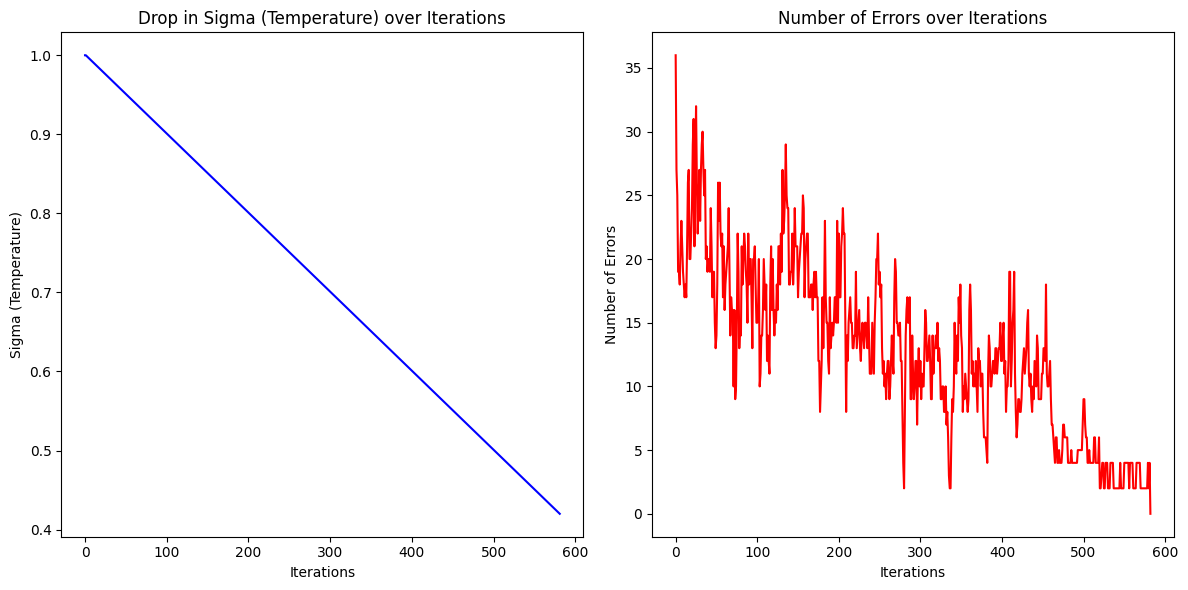



1 9 4 | 7 8 6 | 5 3 2 
5 7 8 | 9 2 3 | 1 4 6 
2 6 3 | 4 1 5 | 7 8 9 
---------------------
9 1 7 | 8 3 4 | 6 2 5 
4 5 6 | 2 9 1 | 3 7 8 
8 3 2 | 5 6 7 | 9 1 4 
---------------------
6 4 5 | 3 7 2 | 8 9 1 
3 2 9 | 1 5 8 | 4 6 7 
7 8 1 | 6 4 9 | 2 5 3 


In [30]:
import random
import numpy as np
import math 
import statistics 
import matplotlib.pyplot as plt
from random import choice

startingSudoku = """
                    094006032
                    570020000
                    200005080
                    907800605
                    006090300
                    830007010
                    005000001
                    020150467
                    700600203
                """

sudoku = np.array([[int(i) for i in line] for line in startingSudoku.split()])

def PrintSudoku(sudoku):
    print("\n")
    for i in range(len(sudoku)):
        line = ""
        if i == 3 or i == 6:
            print("---------------------")
        for j in range(len(sudoku[i])):
            if j == 3 or j == 6:
                line += "| "
            line += str(sudoku[i,j])+" "
        print(line)

def FixSudokuValues(fixed_sudoku):
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                fixed_sudoku[i,j] = 1
    return(fixed_sudoku)

# Cost Function    
def CalculateNumberOfErrors(sudoku):
    numberOfErrors = 0 
    for i in range (0,9):
        numberOfErrors += CalculateNumberOfErrorsRowColumn(i ,i ,sudoku)
    return(numberOfErrors)

def CalculateNumberOfErrorsRowColumn(row, column, sudoku):
    numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))
    return(numberOfErrors)

def CreateList3x3Blocks ():
    finalListOfBlocks = []
    for r in range (0,9):
        tmpList = []
        block1 = [i + 3*((r)%3) for i in range(0,3)]
        block2 = [i + 3*math.trunc((r)/3) for i in range(0,3)]
        for x in block1:
            for y in block2:
                tmpList.append([x,y])
        finalListOfBlocks.append(tmpList)
    return(finalListOfBlocks)

def RandomlyFill3x3Blocks(sudoku, listOfBlocks):
    for block in listOfBlocks:
        for box in block:
            if sudoku[box[0],box[1]] == 0:
                currentBlock = sudoku[block[0][0]:(block[-1][0]+1),block[0][1]:(block[-1][1]+1)]
                sudoku[box[0],box[1]] = choice([i for i in range(1,10) if i not in currentBlock])
    return sudoku

def SumOfOneBlock (sudoku, oneBlock):
    finalSum = 0
    for box in oneBlock:
        finalSum += sudoku[box[0], box[1]]
    return(finalSum)

def TwoRandomBoxesWithinBlock(fixedSudoku, block):
    while (1):
        firstBox = random.choice(block)
        secondBox = choice([box for box in block if box is not firstBox ])
        if fixedSudoku[firstBox[0], firstBox[1]] != 1 and fixedSudoku[secondBox[0], secondBox[1]] != 1:
            return([firstBox, secondBox])

def FlipBoxes(sudoku, boxesToFlip):
    proposedSudoku = np.copy(sudoku)
    placeHolder = proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]]
    proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]] = proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]]
    proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]] = placeHolder
    return (proposedSudoku)

def ProposedState (sudoku, fixedSudoku, listOfBlocks):
    randomBlock = random.choice(listOfBlocks)

    if SumOfOneBlock(fixedSudoku, randomBlock) > 6:  
        return(sudoku, 1, 1)
    boxesToFlip = TwoRandomBoxesWithinBlock(fixedSudoku, randomBlock)
    proposedSudoku = FlipBoxes(sudoku,  boxesToFlip)
    return([proposedSudoku, boxesToFlip])

def LinearCoolingSchedule(initial_sigma, current_iteration, max_iterations):
    """
    Linear cooling schedule function. The temperature is decreased linearly over the iterations.
    """
    alpha = initial_sigma / max_iterations  # Cooling rate
    return initial_sigma - alpha * current_iteration

def ChooseNewState (currentSudoku, fixedSudoku, listOfBlocks, sigma):
    proposal = ProposedState(currentSudoku, fixedSudoku, listOfBlocks)
    newSudoku = proposal[0]
    boxesToCheck = proposal[1]
    currentCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], currentSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], currentSudoku)
    newCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], newSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], newSudoku)
    costDifference = newCost - currentCost
    rho = math.exp(-costDifference/sigma)
    if(np.random.uniform(1,0,1) < rho):
        return([newSudoku, costDifference])
    return([currentSudoku, 0])

def ChooseNumberOfItterations(fixed_sudoku):
    numberOfItterations = 0
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                numberOfItterations += 1
    return numberOfItterations

def CalculateInitialSigma (sudoku, fixedSudoku, listOfBlocks):
    listOfDifferences = []
    tmpSudoku = sudoku
    for i in range(1,10):
        tmpSudoku = ProposedState(tmpSudoku, fixedSudoku, listOfBlocks)[0]
        listOfDifferences.append(CalculateNumberOfErrors(tmpSudoku))
    return (statistics.pstdev(listOfDifferences))

def solveSudoku (sudoku):
    solutionFound = 0
    max_iterations = 1000  # Maximum number of iterations
    initial_sigma = 1.0  # Initial temperature (sigma)
    current_iteration = 0
    
    sigma_history = []  # To track the sigma values
    error_history = []  # To track the error values
    
    while (solutionFound == 0):
        stuckCount = 0
        fixedSudoku = np.copy(sudoku)
        FixSudokuValues(fixedSudoku)
        listOfBlocks = CreateList3x3Blocks()
        tmpSudoku = RandomlyFill3x3Blocks(sudoku, listOfBlocks)
        sigma = initial_sigma
        score = CalculateNumberOfErrors(tmpSudoku)
        itterations = ChooseNumberOfItterations(fixedSudoku)

        error_history.append(score)  # Store initial error count
        
        while solutionFound == 0:
            previousScore = score
            for i in range(0, itterations):
                newState = ChooseNewState(tmpSudoku, fixedSudoku, listOfBlocks, sigma)
                tmpSudoku = newState[0]
                scoreDiff = newState[1]
                score += scoreDiff

            sigma_history.append(sigma)  # Store the current sigma value
            sigma = LinearCoolingSchedule(initial_sigma, current_iteration, max_iterations)
            current_iteration += 1
            
            error_history.append(score)  # Track error count over iterations

            if score <= 0:
                solutionFound = 1
                break
            
            if score >= previousScore:
                stuckCount += 1
            else:
                stuckCount = 0
            if stuckCount > 80:
                sigma += 2

    # Plotting the drop in temperature (sigma) over iterations
    plt.figure(figsize=(12, 6))

    # Plotting sigma
    plt.subplot(1, 2, 1)
    plt.plot(sigma_history, color="blue", label="Sigma")
    plt.title("Drop in Sigma (Temperature) over Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Sigma (Temperature)")

    # Plotting error history
    plt.subplot(1, 2, 2)
    plt.plot(error_history, color="red", label="Number of Errors")
    plt.title("Number of Errors over Iterations")
    plt.xlabel("Iterations")
    plt.ylabel("Number of Errors")

    plt.tight_layout()
    plt.show()

    return tmpSudoku

# Call the solver and print the solution
solution = solveSudoku(sudoku)
PrintSudoku(solution)


## Experiment 2: Exponential (Geometric) Cooling
The temperature decays geometrically:
$$ T_{k+1} = \alpha \cdot T_k $$
where $0.8 < \alpha < 0.99$. This allows for a slow decay at the beginning (high exploration) and faster convergence at the end.

## Grid Representation & Neighbor Generation
To reduce the search space, we treat the grid as a collection of nine 3x3 blocks. 
*   **Initialization**: We randomly fill each block with numbers 1-9 (respecting fixed digits).
*   **Swapping**: When generating a neighbor state, we swap two non-fixed numbers *within the same block*. This ensures the block remains valid.

In [31]:
import random
import numpy as np
import math 
from random import choice
import statistics 

startingSudoku = """
                    094006032
                    570020000
                    200005080
                    907800605
                    006090300
                    830007010
                    005000001
                    020150467
                    700600203
                """

sudoku = np.array([[int(i) for i in line] for line in startingSudoku.split()])

def PrintSudoku(sudoku):
    print("\n")
    for i in range(len(sudoku)):
        line = ""
        if i == 3 or i == 6:
            print("---------------------")
        for j in range(len(sudoku[i])):
            if j == 3 or j == 6:
                line += "| "
            line += str(sudoku[i,j])+" "
        print(line)

def FixSudokuValues(fixed_sudoku):
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                fixed_sudoku[i,j] = 1
    
    return(fixed_sudoku)

# Cost Function    
def CalculateNumberOfErrors(sudoku):
    numberOfErrors = 0 
    for i in range (0,9):
        numberOfErrors += CalculateNumberOfErrorsRowColumn(i ,i ,sudoku)
    return(numberOfErrors)

def CalculateNumberOfErrorsRowColumn(row, column, sudoku):
    numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))
    return(numberOfErrors)


def CreateList3x3Blocks ():
    finalListOfBlocks = []
    for r in range (0,9):
        tmpList = []
        block1 = [i + 3*((r)%3) for i in range(0,3)]
        block2 = [i + 3*math.trunc((r)/3) for i in range(0,3)]
        for x in block1:
            for y in block2:
                tmpList.append([x,y])
        finalListOfBlocks.append(tmpList)
    return(finalListOfBlocks)

def RandomlyFill3x3Blocks(sudoku, listOfBlocks):
    for block in listOfBlocks:
        for box in block:
            if sudoku[box[0],box[1]] == 0:
                currentBlock = sudoku[block[0][0]:(block[-1][0]+1),block[0][1]:(block[-1][1]+1)]
                sudoku[box[0],box[1]] = choice([i for i in range(1,10) if i not in currentBlock])
    return sudoku

def SumOfOneBlock (sudoku, oneBlock):
    finalSum = 0
    for box in oneBlock:
        finalSum += sudoku[box[0], box[1]]
    return(finalSum)

def TwoRandomBoxesWithinBlock(fixedSudoku, block):
    while (1):
        firstBox = random.choice(block)
        secondBox = choice([box for box in block if box is not firstBox ])

        if fixedSudoku[firstBox[0], firstBox[1]] != 1 and fixedSudoku[secondBox[0], secondBox[1]] != 1:
            return([firstBox, secondBox])

def FlipBoxes(sudoku, boxesToFlip):
    proposedSudoku = np.copy(sudoku)
    placeHolder = proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]]
    proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]] = proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]]
    proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]] = placeHolder
    return (proposedSudoku)

def ProposedState (sudoku, fixedSudoku, listOfBlocks):
    randomBlock = random.choice(listOfBlocks)

    if SumOfOneBlock(fixedSudoku, randomBlock) > 6:  
        return(sudoku, 1, 1)
    boxesToFlip = TwoRandomBoxesWithinBlock(fixedSudoku, randomBlock)
    proposedSudoku = FlipBoxes(sudoku,  boxesToFlip)
    return([proposedSudoku, boxesToFlip])

def ChooseNewState (currentSudoku, fixedSudoku, listOfBlocks, sigma):
    proposal = ProposedState(currentSudoku, fixedSudoku, listOfBlocks)
    newSudoku = proposal[0]
    boxesToCheck = proposal[1]
    currentCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], currentSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], currentSudoku)
    newCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], newSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], newSudoku)
    # currentCost = CalculateNumberOfErrors(currentSudoku)
    # newCost = CalculateNumberOfErrors(newSudoku)
    costDifference = newCost - currentCost
    rho = math.exp(-costDifference/sigma)
    if(np.random.uniform(1,0,1) < rho):
        return([newSudoku, costDifference])
    return([currentSudoku, 0])


def ChooseNumberOfItterations(fixed_sudoku):
    numberOfItterations = 0
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                numberOfItterations += 1
    return numberOfItterations

def CalculateInitialSigma (sudoku, fixedSudoku, listOfBlocks):
    listOfDifferences = []
    tmpSudoku = sudoku
    for i in range(1,10):
        tmpSudoku = ProposedState(tmpSudoku, fixedSudoku, listOfBlocks)[0]
        listOfDifferences.append(CalculateNumberOfErrors(tmpSudoku))
    return (statistics.pstdev(listOfDifferences))


# Exponential cooling function
def exponential_cooling(T_start, alpha, iteration):
    return T_start * (alpha ** iteration)

def solveSudoku(sudoku):
    #f = open("demofile2.txt", "a")
    solutionFound = 0
    T_start = 100  # Initial temperature
    alpha = 0.99  # Cooling factor (smaller alpha results in slower cooling)
    
    while (solutionFound == 0):
        stuckCount = 0
        fixedSudoku = np.copy(sudoku)
        PrintSudoku(sudoku)
        FixSudokuValues(fixedSudoku)
        listOfBlocks = CreateList3x3Blocks()
        tmpSudoku = RandomlyFill3x3Blocks(sudoku, listOfBlocks)
        sigma = CalculateInitialSigma(sudoku, fixedSudoku, listOfBlocks)
        score = CalculateNumberOfErrors(tmpSudoku)
        itterations = ChooseNumberOfItterations(fixedSudoku)
        
        if score <= 0:
            solutionFound = 1

        iteration = 0
        while solutionFound == 0:
            previousScore = score
            for i in range(0, itterations):
                newState = ChooseNewState(tmpSudoku, fixedSudoku, listOfBlocks, sigma)
                tmpSudoku = newState[0]
                scoreDiff = newState[1]
                score += scoreDiff
                print('score',score)
                #f.write(str(score) + '\n')
                if score <= 0:
                    solutionFound = 1
                    break

            # Update the temperature using the exponential cooling function
            sigma = exponential_cooling(T_start, alpha, iteration)
            iteration += 1  # Increment iteration count for cooling
            print('Sigma value:',sigma)

            if score <= 0:
                solutionFound = 1
                break

            if score >= previousScore:
                stuckCount += 1
            else:
                stuckCount = 0

            # Increase sigma if the algorithm is stuck (to encourage more exploration)
            if stuckCount > 80:
                sigma += 2

            if CalculateNumberOfErrors(tmpSudoku) == 0:
                PrintSudoku(tmpSudoku)
                break

    #f.close()
    return(tmpSudoku)

solution = solveSudoku(sudoku)
print(CalculateNumberOfErrors(solution))
PrintSudoku(solution)




0 9 4 | 0 0 6 | 0 3 2 
5 7 0 | 0 2 0 | 0 0 0 
2 0 0 | 0 0 5 | 0 8 0 
---------------------
9 0 7 | 8 0 0 | 6 0 5 
0 0 6 | 0 9 0 | 3 0 0 
8 3 0 | 0 0 7 | 0 1 0 
---------------------
0 0 5 | 0 0 0 | 0 0 1 
0 2 0 | 1 5 0 | 4 6 7 
7 0 0 | 6 0 0 | 2 0 3 
score 43
score 43
score 39
score 39
score 39
score 39
score 37
score 38
score 37
score 38
score 41
score 39
score 39
score 40
score 38
score 38
score 35
score 33
score 33
score 31
score 33
score 32
score 32
score 33
score 34
score 30
score 30
score 30
score 30
score 31
score 30
score 30
score 30
score 31
score 31
Sigma value: 100.0
score 31
score 32
score 34
score 33
score 35
score 32
score 34
score 35
score 34
score 32
score 30
score 33
score 36
score 37
score 39
score 38
score 39
score 38
score 38
score 38
score 37
score 37
score 38
score 38
score 40
score 36
score 37
score 38
score 39
score 39
score 40
score 40
score 41
score 40
score 38
Sigma value: 99.0
score 38
score 38
score 38
score 36
score 38
score 36
score 38
score 36
score 36

OverflowError: math range error

## Experiment 2: Exponential (Geometric) Cooling
The temperature decays geometrically:
$$ T_{k+1} = \alpha \cdot T_k $$
where $0.8 < \alpha < 0.99$. This allows for a slow decay at the beginning (high exploration) and faster convergence at the end.

## Grid Representation & Neighbor Generation
To reduce the search space, we treat the grid as a collection of nine 3x3 blocks. 
*   **Initialization**: We randomly fill each block with numbers 1-9 (respecting fixed digits).
*   **Swapping**: When generating a neighbor state, we swap two non-fixed numbers *within the same block*. This ensures the block remains valid.



0 9 4 | 0 0 6 | 0 3 2 
5 7 0 | 0 2 0 | 0 0 0 
2 0 0 | 0 0 5 | 0 8 0 
---------------------
9 0 7 | 8 0 0 | 6 0 5 
0 0 6 | 0 9 0 | 3 0 0 
8 3 0 | 0 0 7 | 0 1 0 
---------------------
0 0 5 | 0 0 0 | 0 0 1 
0 2 0 | 1 5 0 | 4 6 7 
7 0 0 | 6 0 0 | 2 0 3 


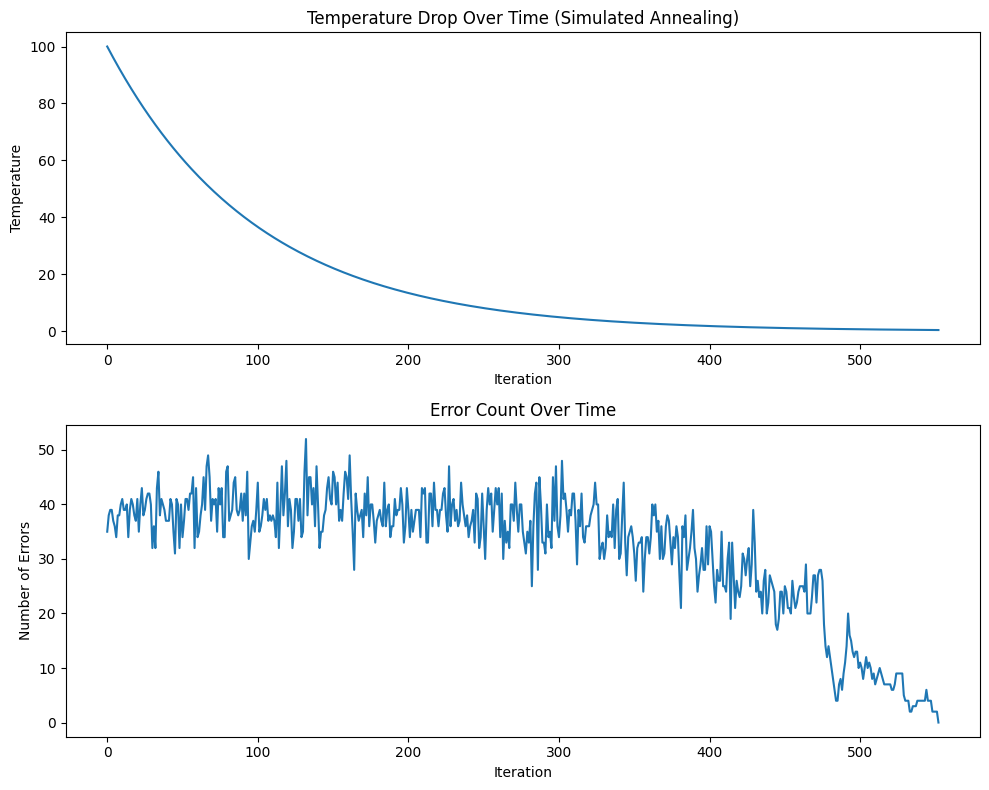



1 9 4 | 7 8 6 | 5 3 2 
5 7 8 | 9 2 3 | 1 4 6 
2 6 3 | 4 1 5 | 7 8 9 
---------------------
9 1 7 | 8 3 4 | 6 2 5 
4 5 6 | 2 9 1 | 3 7 8 
8 3 2 | 5 6 7 | 9 1 4 
---------------------
6 4 5 | 3 7 2 | 8 9 1 
3 2 9 | 1 5 8 | 4 6 7 
7 8 1 | 6 4 9 | 2 5 3 


In [ ]:
import random
import numpy as np
import math 
from random import choice
import statistics
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

startingSudoku = """
                    094006032
                    570020000
                    200005080
                    907800605
                    006090300
                    830007010
                    005000001
                    020150467
                    700600203
                """

sudoku = np.array([[int(i) for i in line] for line in startingSudoku.split()])

def PrintSudoku(sudoku):
    print("\n")
    for i in range(len(sudoku)):
        line = ""
        if i == 3 or i == 6:
            print("---------------------")
        for j in range(len(sudoku[i])):
            if j == 3 or j == 6:
                line += "| "
            line += str(sudoku[i,j])+" "
        print(line)

def FixSudokuValues(fixed_sudoku):
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                fixed_sudoku[i,j] = 1
    
    return(fixed_sudoku)

# Cost Function    
def CalculateNumberOfErrors(sudoku):
    numberOfErrors = 0 
    for i in range (0,9):
        numberOfErrors += CalculateNumberOfErrorsRowColumn(i ,i ,sudoku)
    return(numberOfErrors)

def CalculateNumberOfErrorsRowColumn(row, column, sudoku):
    numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))
    return(numberOfErrors)


def CreateList3x3Blocks ():
    finalListOfBlocks = []
    for r in range (0,9):
        tmpList = []
        block1 = [i + 3*((r)%3) for i in range(0,3)]
        block2 = [i + 3*math.trunc((r)/3) for i in range(0,3)]
        for x in block1:
            for y in block2:
                tmpList.append([x,y])
        finalListOfBlocks.append(tmpList)
    return(finalListOfBlocks)

def RandomlyFill3x3Blocks(sudoku, listOfBlocks):
    for block in listOfBlocks:
        for box in block:
            if sudoku[box[0],box[1]] == 0:
                currentBlock = sudoku[block[0][0]:(block[-1][0]+1),block[0][1]:(block[-1][1]+1)]
                sudoku[box[0],box[1]] = choice([i for i in range(1,10) if i not in currentBlock])
    return sudoku

def SumOfOneBlock (sudoku, oneBlock):
    finalSum = 0
    for box in oneBlock:
        finalSum += sudoku[box[0], box[1]]
    return(finalSum)

def TwoRandomBoxesWithinBlock(fixedSudoku, block):
    while (1):
        firstBox = random.choice(block)
        secondBox = choice([box for box in block if box is not firstBox ])

        if fixedSudoku[firstBox[0], firstBox[1]] != 1 and fixedSudoku[secondBox[0], secondBox[1]] != 1:
            return([firstBox, secondBox])

def FlipBoxes(sudoku, boxesToFlip):
    proposedSudoku = np.copy(sudoku)
    placeHolder = proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]]
    proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]] = proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]]
    proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]] = placeHolder
    return (proposedSudoku)

def ProposedState (sudoku, fixedSudoku, listOfBlocks):
    randomBlock = random.choice(listOfBlocks)

    if SumOfOneBlock(fixedSudoku, randomBlock) > 6:  
        return(sudoku, 1, 1)
    boxesToFlip = TwoRandomBoxesWithinBlock(fixedSudoku, randomBlock)
    proposedSudoku = FlipBoxes(sudoku,  boxesToFlip)
    return([proposedSudoku, boxesToFlip])

def ChooseNewState (currentSudoku, fixedSudoku, listOfBlocks, sigma):
    proposal = ProposedState(currentSudoku, fixedSudoku, listOfBlocks)
    newSudoku = proposal[0]
    boxesToCheck = proposal[1]
    currentCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], currentSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], currentSudoku)
    newCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], newSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], newSudoku)
    costDifference = newCost - currentCost
    rho = math.exp(-costDifference/sigma)
    if(np.random.uniform(1,0,1) < rho):
        return([newSudoku, costDifference])
    return([currentSudoku, 0])


def ChooseNumberOfItterations(fixed_sudoku):
    numberOfItterations = 0
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                numberOfItterations += 1
    return numberOfItterations

def CalculateInitialSigma (sudoku, fixedSudoku, listOfBlocks):
    listOfDifferences = []
    tmpSudoku = sudoku
    for i in range(1,10):
        tmpSudoku = ProposedState(tmpSudoku, fixedSudoku, listOfBlocks)[0]
        listOfDifferences.append(CalculateNumberOfErrors(tmpSudoku))
    return (statistics.pstdev(listOfDifferences))


# Exponential cooling function
def exponential_cooling(T_start, alpha, iteration):
    return T_start * (alpha ** iteration)

def solveSudoku(sudoku):
    solutionFound = 0
    T_start = 100  # Initial temperature
    alpha = 0.99  # Cooling factor (smaller alpha results in slower cooling)
    
    temperature_history = []  # List to store the temperature at each iteration
    error_history = []  # List to store the number of errors at each iteration

    while (solutionFound == 0):
        stuckCount = 0
        fixedSudoku = np.copy(sudoku)
        PrintSudoku(sudoku)
        FixSudokuValues(fixedSudoku)
        listOfBlocks = CreateList3x3Blocks()
        tmpSudoku = RandomlyFill3x3Blocks(sudoku, listOfBlocks)
        sigma = CalculateInitialSigma(sudoku, fixedSudoku, listOfBlocks)
        score = CalculateNumberOfErrors(tmpSudoku)
        itterations = ChooseNumberOfItterations(fixedSudoku)
        
        if score <= 0:
            solutionFound = 1

        iteration = 0
        while solutionFound == 0:
            previousScore = score
            for i in range(0, itterations):
                newState = ChooseNewState(tmpSudoku, fixedSudoku, listOfBlocks, sigma)
                tmpSudoku = newState[0]
                scoreDiff = newState[1]
                score += scoreDiff
                if score <= 0:
                    solutionFound = 1
                    break

            # Update the temperature using the exponential cooling function
            sigma = exponential_cooling(T_start, alpha, iteration)
            temperature_history.append(sigma)  # Store the temperature
            error_history.append(score)  # Store the number of errors
            iteration += 1  # Increment iteration count for cooling

            if score <= 0:
                solutionFound = 1
                break

            if score >= previousScore:
                stuckCount += 1
            else:
                stuckCount = 0

            # Increase sigma if the algorithm is stuck (to encourage more exploration)
            if stuckCount > 80:
                sigma += 2

            if CalculateNumberOfErrors(tmpSudoku) == 0:
                PrintSudoku(tmpSudoku)
                break

    # After the algorithm completes, plot the temperature and error history
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(temperature_history)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Temperature")
    ax1.set_title("Temperature Drop Over Time (Simulated Annealing)")

    ax2.plot(error_history)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Number of Errors")
    ax2.set_title("Error Count Over Time")

    plt.tight_layout()
    plt.show()

    return(tmpSudoku)

solution = solveSudoku(sudoku)
PrintSudoku(solution)


## Experiment 3: Adaptive Cooling
Adaptive cooling schedules adjust the temperature based on the statistical properties of the search (e.g., standard deviation of costs). If the algorithm is stuck (low variance), it might heat up; if it's converging, it cools down.

## Grid Representation & Neighbor Generation
To reduce the search space, we treat the grid as a collection of nine 3x3 blocks. 
*   **Initialization**: We randomly fill each block with numbers 1-9 (respecting fixed digits).
*   **Swapping**: When generating a neighbor state, we swap two non-fixed numbers *within the same block*. This ensures the block remains valid.

In [ ]:
import random
import numpy as np
import math 
from random import choice
import statistics 

startingSudoku = """
                    094006032
                    570020000
                    200005080
                    907800605
                    006090300
                    830007010
                    005000001
                    020150467
                    700600203
                """

sudoku = np.array([[int(i) for i in line] for line in startingSudoku.split()])

def PrintSudoku(sudoku):
    print("\n")
    for i in range(len(sudoku)):
        line = ""
        if i == 3 or i == 6:
            print("---------------------")
        for j in range(len(sudoku[i])):
            if j == 3 or j == 6:
                line += "| "
            line += str(sudoku[i,j])+" "
        print(line)

def FixSudokuValues(fixed_sudoku):
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                fixed_sudoku[i,j] = 1
    return(fixed_sudoku)

# Cost Function    
def CalculateNumberOfErrors(sudoku):
    numberOfErrors = 0 
    for i in range (0,9):
        numberOfErrors += CalculateNumberOfErrorsRowColumn(i ,i ,sudoku)
    return(numberOfErrors)

def CalculateNumberOfErrorsRowColumn(row, column, sudoku):
    numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))
    return(numberOfErrors)


def CreateList3x3Blocks ():
    finalListOfBlocks = []
    for r in range (0,9):
        tmpList = []
        block1 = [i + 3*((r)%3) for i in range(0,3)]
        block2 = [i + 3*math.trunc((r)/3) for i in range(0,3)]
        for x in block1:
            for y in block2:
                tmpList.append([x,y])
        finalListOfBlocks.append(tmpList)
    return(finalListOfBlocks)

def RandomlyFill3x3Blocks(sudoku, listOfBlocks):
    for block in listOfBlocks:
        for box in block:
            if sudoku[box[0],box[1]] == 0:
                currentBlock = sudoku[block[0][0]:(block[-1][0]+1),block[0][1]:(block[-1][1]+1)]
                sudoku[box[0],box[1]] = choice([i for i in range(1,10) if i not in currentBlock])
    return sudoku

def SumOfOneBlock (sudoku, oneBlock):
    finalSum = 0
    for box in oneBlock:
        finalSum += sudoku[box[0], box[1]]
    return(finalSum)

def TwoRandomBoxesWithinBlock(fixedSudoku, block):
    while (1):
        firstBox = random.choice(block)
        secondBox = choice([box for box in block if box is not firstBox ])
        if fixedSudoku[firstBox[0], firstBox[1]] != 1 and fixedSudoku[secondBox[0], secondBox[1]] != 1:
            return([firstBox, secondBox])

def FlipBoxes(sudoku, boxesToFlip):
    proposedSudoku = np.copy(sudoku)
    placeHolder = proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]]
    proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]] = proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]]
    proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]] = placeHolder
    return (proposedSudoku)

def ProposedState (sudoku, fixedSudoku, listOfBlocks):
    randomBlock = random.choice(listOfBlocks)

    if SumOfOneBlock(fixedSudoku, randomBlock) > 6:  
        return(sudoku, 1, 1)
    boxesToFlip = TwoRandomBoxesWithinBlock(fixedSudoku, randomBlock)
    proposedSudoku = FlipBoxes(sudoku,  boxesToFlip)
    return([proposedSudoku, boxesToFlip])

def AdaptiveSigmaCooling(score):
    """
    Adaptive cooling strategy for sigma based on the score of the current state.
    - Higher score: Higher temperature (sigma)
    - Lower score: Lower temperature (sigma)
    """
    if score > 50:
        return 1.0  # High temperature for a high number of errors
    elif score > 20:
        return 0.5  # Medium temperature for moderate errors
    else:
        return 0.1  # Low temperature as the solution nears completion

def ChooseNewState (currentSudoku, fixedSudoku, listOfBlocks, sigma):
    proposal = ProposedState(currentSudoku, fixedSudoku, listOfBlocks)
    newSudoku = proposal[0]
    boxesToCheck = proposal[1]
    currentCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], currentSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], currentSudoku)
    newCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], newSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], newSudoku)
    costDifference = newCost - currentCost
    rho = math.exp(-costDifference/sigma)
    if(np.random.uniform(1,0,1) < rho):
        return([newSudoku, costDifference])
    return([currentSudoku, 0])

def ChooseNumberOfItterations(fixed_sudoku):
    numberOfItterations = 0
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                numberOfItterations += 1
    return numberOfItterations

def CalculateInitialSigma (sudoku, fixedSudoku, listOfBlocks):
    listOfDifferences = []
    tmpSudoku = sudoku
    for i in range(1,10):
        tmpSudoku = ProposedState(tmpSudoku, fixedSudoku, listOfBlocks)[0]
        listOfDifferences.append(CalculateNumberOfErrors(tmpSudoku))
    return (statistics.pstdev(listOfDifferences))

def solveSudoku (sudoku):
    solutionFound = 0
    while (solutionFound == 0):
        decreaseFactor = 0.99
        stuckCount = 0
        fixedSudoku = np.copy(sudoku)
        PrintSudoku(sudoku)
        FixSudokuValues(fixedSudoku)
        listOfBlocks = CreateList3x3Blocks()
        tmpSudoku = RandomlyFill3x3Blocks(sudoku, listOfBlocks)
        sigma = CalculateInitialSigma(sudoku, fixedSudoku, listOfBlocks)
        score = CalculateNumberOfErrors(tmpSudoku)
        itterations = ChooseNumberOfItterations(fixedSudoku)
        if score <= 0:
            solutionFound = 1

        while solutionFound == 0:
            previousScore = score
            for i in range (0, itterations):
                newState = ChooseNewState(tmpSudoku, fixedSudoku, listOfBlocks, sigma)
                tmpSudoku = newState[0]
                scoreDiff = newState[1]
                score += scoreDiff
                if score <= 0:
                    solutionFound = 1
                    break

            # Apply the adaptive sigma cooling strategy
            sigma = AdaptiveSigmaCooling(score)
            print('sigma value', sigma)
            if score <= 0:
                solutionFound = 1
                break
            if score >= previousScore:
                stuckCount += 1
            else:
                stuckCount = 0
            if (stuckCount > 80):
                sigma += 2
            if(CalculateNumberOfErrors(tmpSudoku)==0):
                PrintSudoku(tmpSudoku)
                break
    return(tmpSudoku)

solution = solveSudoku(sudoku)
PrintSudoku(solution)




0 9 4 | 0 0 6 | 0 3 2 
5 7 0 | 0 2 0 | 0 0 0 
2 0 0 | 0 0 5 | 0 8 0 
---------------------
9 0 7 | 8 0 0 | 6 0 5 
0 0 6 | 0 9 0 | 3 0 0 
8 3 0 | 0 0 7 | 0 1 0 
---------------------
0 0 5 | 0 0 0 | 0 0 1 
0 2 0 | 1 5 0 | 4 6 7 
7 0 0 | 6 0 0 | 2 0 3 
sigma value 0.5
sigma value 0.5
sigma value 0.5
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value 0.1
sigma value

## Experiment 3: Adaptive Cooling
Adaptive cooling schedules adjust the temperature based on the statistical properties of the search (e.g., standard deviation of costs). If the algorithm is stuck (low variance), it might heat up; if it's converging, it cools down.

## Grid Representation & Neighbor Generation
To reduce the search space, we treat the grid as a collection of nine 3x3 blocks. 
*   **Initialization**: We randomly fill each block with numbers 1-9 (respecting fixed digits).
*   **Swapping**: When generating a neighbor state, we swap two non-fixed numbers *within the same block*. This ensures the block remains valid.



0 9 4 | 0 0 6 | 0 3 2 
5 7 0 | 0 2 0 | 0 0 0 
2 0 0 | 0 0 5 | 0 8 0 
---------------------
9 0 7 | 8 0 0 | 6 0 5 
0 0 6 | 0 9 0 | 3 0 0 
8 3 0 | 0 0 7 | 0 1 0 
---------------------
0 0 5 | 0 0 0 | 0 0 1 
0 2 0 | 1 5 0 | 4 6 7 
7 0 0 | 6 0 0 | 2 0 3 


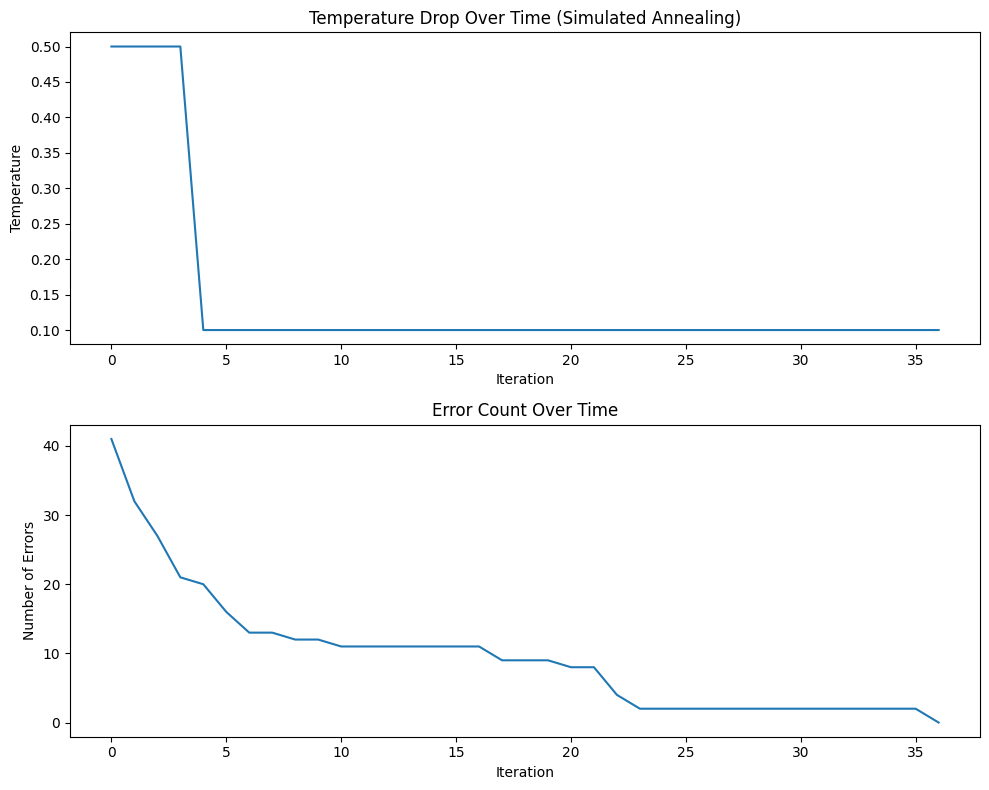



1 9 4 | 7 8 6 | 5 3 2 
5 7 8 | 9 2 3 | 1 4 6 
2 6 3 | 4 1 5 | 7 8 9 
---------------------
9 1 7 | 8 3 4 | 6 2 5 
4 5 6 | 2 9 1 | 3 7 8 
8 3 2 | 5 6 7 | 9 1 4 
---------------------
6 4 5 | 3 7 2 | 8 9 1 
3 2 9 | 1 5 8 | 4 6 7 
7 8 1 | 6 4 9 | 2 5 3 


In [ ]:
import random
import numpy as np
import math 
from random import choice
import statistics
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

startingSudoku = """
                    094006032
                    570020000
                    200005080
                    907800605
                    006090300
                    830007010
                    005000001
                    020150467
                    700600203
                """

sudoku = np.array([[int(i) for i in line] for line in startingSudoku.split()])

def PrintSudoku(sudoku):
    print("\n")
    for i in range(len(sudoku)):
        line = ""
        if i == 3 or i == 6:
            print("---------------------")
        for j in range(len(sudoku[i])):
            if j == 3 or j == 6:
                line += "| "
            line += str(sudoku[i,j])+" "
        print(line)

def FixSudokuValues(fixed_sudoku):
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                fixed_sudoku[i,j] = 1
    return(fixed_sudoku)

# Cost Function    
def CalculateNumberOfErrors(sudoku):
    numberOfErrors = 0 
    for i in range (0,9):
        numberOfErrors += CalculateNumberOfErrorsRowColumn(i ,i ,sudoku)
    return(numberOfErrors)

def CalculateNumberOfErrorsRowColumn(row, column, sudoku):
    numberOfErrors = (9 - len(np.unique(sudoku[:,column]))) + (9 - len(np.unique(sudoku[row,:])))
    return(numberOfErrors)

def CreateList3x3Blocks ():
    finalListOfBlocks = []
    for r in range (0,9):
        tmpList = []
        block1 = [i + 3*((r)%3) for i in range(0,3)]
        block2 = [i + 3*math.trunc((r)/3) for i in range(0,3)]
        for x in block1:
            for y in block2:
                tmpList.append([x,y])
        finalListOfBlocks.append(tmpList)
    return(finalListOfBlocks)

def RandomlyFill3x3Blocks(sudoku, listOfBlocks):
    for block in listOfBlocks:
        for box in block:
            if sudoku[box[0],box[1]] == 0:
                currentBlock = sudoku[block[0][0]:(block[-1][0]+1),block[0][1]:(block[-1][1]+1)]
                sudoku[box[0],box[1]] = choice([i for i in range(1,10) if i not in currentBlock])
    return sudoku

def SumOfOneBlock (sudoku, oneBlock):
    finalSum = 0
    for box in oneBlock:
        finalSum += sudoku[box[0], box[1]]
    return(finalSum)

def TwoRandomBoxesWithinBlock(fixedSudoku, block):
    while (1):
        firstBox = random.choice(block)
        secondBox = choice([box for box in block if box is not firstBox ])
        if fixedSudoku[firstBox[0], firstBox[1]] != 1 and fixedSudoku[secondBox[0], secondBox[1]] != 1:
            return([firstBox, secondBox])

def FlipBoxes(sudoku, boxesToFlip):
    proposedSudoku = np.copy(sudoku)
    placeHolder = proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]]
    proposedSudoku[boxesToFlip[0][0], boxesToFlip[0][1]] = proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]]
    proposedSudoku[boxesToFlip[1][0], boxesToFlip[1][1]] = placeHolder
    return (proposedSudoku)

def ProposedState (sudoku, fixedSudoku, listOfBlocks):
    randomBlock = random.choice(listOfBlocks)

    if SumOfOneBlock(fixedSudoku, randomBlock) > 6:  
        return(sudoku, 1, 1)
    boxesToFlip = TwoRandomBoxesWithinBlock(fixedSudoku, randomBlock)
    proposedSudoku = FlipBoxes(sudoku,  boxesToFlip)
    return([proposedSudoku, boxesToFlip])

def AdaptiveSigmaCooling(score):
    """
    Adaptive cooling strategy for sigma based on the score of the current state.
    - Higher score: Higher temperature (sigma)
    - Lower score: Lower temperature (sigma)
    """
    if score > 50:
        return 1.0  # High temperature for a high number of errors
    elif score > 20:
        return 0.5  # Medium temperature for moderate errors
    else:
        return 0.1  # Low temperature as the solution nears completion

def ChooseNewState (currentSudoku, fixedSudoku, listOfBlocks, sigma):
    proposal = ProposedState(currentSudoku, fixedSudoku, listOfBlocks)
    newSudoku = proposal[0]
    boxesToCheck = proposal[1]
    currentCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], currentSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], currentSudoku)
    newCost = CalculateNumberOfErrorsRowColumn(boxesToCheck[0][0], boxesToCheck[0][1], newSudoku) + CalculateNumberOfErrorsRowColumn(boxesToCheck[1][0], boxesToCheck[1][1], newSudoku)
    costDifference = newCost - currentCost
    rho = math.exp(-costDifference/sigma)
    if(np.random.uniform(1,0,1) < rho):
        return([newSudoku, costDifference])
    return([currentSudoku, 0])

def ChooseNumberOfItterations(fixed_sudoku):
    numberOfItterations = 0
    for i in range (0,9):
        for j in range (0,9):
            if fixed_sudoku[i,j] != 0:
                numberOfItterations += 1
    return numberOfItterations

def CalculateInitialSigma (sudoku, fixedSudoku, listOfBlocks):
    listOfDifferences = []
    tmpSudoku = sudoku
    for i in range(1,10):
        tmpSudoku = ProposedState(tmpSudoku, fixedSudoku, listOfBlocks)[0]
        listOfDifferences.append(CalculateNumberOfErrors(tmpSudoku))
    return (statistics.pstdev(listOfDifferences))

def solveSudoku (sudoku):
    solutionFound = 0

    temperature_history = []  # List to store temperature values
    error_history = []  # List to store error count at each iteration

    while (solutionFound == 0):
        decreaseFactor = 0.99
        stuckCount = 0
        fixedSudoku = np.copy(sudoku)
        PrintSudoku(sudoku)
        FixSudokuValues(fixedSudoku)
        listOfBlocks = CreateList3x3Blocks()
        tmpSudoku = RandomlyFill3x3Blocks(sudoku, listOfBlocks)
        sigma = CalculateInitialSigma(sudoku, fixedSudoku, listOfBlocks)
        score = CalculateNumberOfErrors(tmpSudoku)
        itterations = ChooseNumberOfItterations(fixedSudoku)
        if score <= 0:
            solutionFound = 1

        while solutionFound == 0:
            previousScore = score
            for i in range (0, itterations):
                newState = ChooseNewState(tmpSudoku, fixedSudoku, listOfBlocks, sigma)
                tmpSudoku = newState[0]
                scoreDiff = newState[1]
                score += scoreDiff
                if score <= 0:
                    solutionFound = 1
                    break

            # Apply the adaptive sigma cooling strategy
            sigma = AdaptiveSigmaCooling(score)
            temperature_history.append(sigma)  # Store the temperature value
            error_history.append(score)  # Store the error count

            if score <= 0:
                solutionFound = 1
                break
            if score >= previousScore:
                stuckCount += 1
            else:
                stuckCount = 0
            if (stuckCount > 80):
                sigma += 2
            if(CalculateNumberOfErrors(tmpSudoku)==0):
                PrintSudoku(tmpSudoku)
                break

    # After the algorithm completes, plot the temperature and error history
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    ax1.plot(temperature_history)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Temperature")
    ax1.set_title("Temperature Drop Over Time (Simulated Annealing)")

    ax2.plot(error_history)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Number of Errors")
    ax2.set_title("Error Count Over Time")

    plt.tight_layout()
    plt.show()

    return(tmpSudoku)

solution = solveSudoku(sudoku)
PrintSudoku(solution)
